# Subset multiome atlas to epiblast -> blood trajectory - RNA

In [59]:
here::i_am("rna/trajectories/infer_trajectory.R")

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(destiny))
suppressPackageStartupMessages(library(batchelor))
suppressPackageStartupMessages(library(uwot))


# Load default settings
source(here::here("settings.R"))
source(here::here("utils.R"))

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/code



In [113]:
## START TEST ##
args <- list()
args$sce <-file.path(io$basedir,"data/processed/rna/SingleCellExperiment.rds")
args$metadataRNA <- file.path(io$basedir,"results/rna/mapping/sample_metadata_after_mapping.txt.gz")
args$metadataATAC <- file.path(io$basedir, '/results/atac/archR/qc/sample_metadata_after_qc.txt.gz')
args$trajectory_name <- "epiblast_blood"
args$celltype_label <- "celltype"
args$outdir <- file.path(io$basedir,"results/epiblast_blood")

args$batch_variable = 'sample'
args$features = 3000
args$npcs <- 25
args$min_dist = 0.3
args$n_neighbors = 25
args$seed = 1234
args$sample <- c('E7.5_rep1','E7.5_rep2','E7.75_rep1','E8.0_rep1','E8.0_rep2','E8.5_rep1','E8.5_rep2','E8.75_rep1','E8.75_rep2')
## END TEST ##

# I/O
dir.create(args$outdir, showWarnings=F, recursive=T)

# Trajectory 
opts$celltypes = c("Epiblast",
                    "Primitive_Streak" ,
                    "Nascent_mesoderm",
                    "ExE_mesoderm",
                    "Mixed_mesoderm",
                    "Allantois",
                    "Mesenchyme",
                    "Haematoendothelial_progenitors",
                    "Endothelium",
                    "Blood_progenitors_1",
                    "Blood_progenitors_2",
                    "Erythroid1",
                    "Erythroid2",
                    "Erythroid3")

BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 16

In [144]:
unique(fread(args$metadataRNA)$celltype)

[1] NA                               "Caudal_epiblast"               
 [3] "ExE_ectoderm"                   "Mixed_mesoderm"                
 [5] "Primitive_Streak"               "Parietal_endoderm"             
 [7] "Somitic_mesoderm"               "Gut"                           
 [9] "Blood_progenitors_1"            "Rostral_neurectoderm"          
[11] "Visceral_endoderm"              "ExE_endoderm"                  
[13] "Nascent_mesoderm"               "Haematoendothelial_progenitors"
[15] "Def._endoderm"                  "Caudal_Mesoderm"               
[17] "Epiblast"                       "Mesenchyme"                    
[19] "Blood_progenitors_2"            "Paraxial_mesoderm"             
[21] "Anterior_Primitive_Streak"      "Surface_ectoderm"              
[23] "Pharyngeal_mesoderm"            "Notochord"                     
[25] "Intermediate_mesoderm"          "PGC"                           
[27] "ExE_mesoderm"                   "Forebrain_Midbrain_Hindbrain"  
[29] "Spinal_cord"                    "Caudal_neurectoderm"           
[31] "Allantois"                      "Endothelium"                   
[33] "Neural_crest"                   "Cardiomyocytes"                
[35] "Erythroid1"                     "NMP"                           
[37] "Erythroid2"                     "Erythroid3"

In [54]:
##########################
## Load sample metadata ##
##########################

sample_metadata <- fread(args$metadataRNA) %>%
  .[pass_rnaQC==TRUE & doublet_call==FALSE] %>%
    merge(.,fread(args$metadataATAC)[,c('cell', 'pass_atacQC')], by='cell') %>%
    .[pass_atacQC==TRUE]

stopifnot(args$celltype_label%in%colnames(sample_metadata))
sample_metadata <- sample_metadata   %>%
  .[,celltype:=eval(as.name(args$celltype_label))] %>%
  .[celltype%in%opts$celltypes] %>%
  .[,celltype:=factor(celltype,levels=opts$celltypes)] %>%
  .[sample%in% args$sample]

table(sample_metadata$celltype)

# Save
fwrite(sample_metadata, file.path(args$outdir,sprintf("%s_sample_metadata.txt.gz",args$trajectory_name)))


                      Epiblast               Primitive_Streak 
                           984                            542 
              Nascent_mesoderm                   ExE_mesoderm 
                          1327                           1173 
                Mixed_mesoderm                      Allantois 
                           265                            653 
                    Mesenchyme Haematoendothelial_progenitors 
                          3123                            913 
                   Endothelium            Blood_progenitors_1 
                           666                            230 
           Blood_progenitors_2                     Erythroid1 
                           565                           1119 
                    Erythroid2                     Erythroid3 
                           939                            187 

In [55]:
#########################
## Load RNA expression ##
#########################
  
sce <- load_SingleCellExperiment(
  file = args$sce, 
  normalise = TRUE, 
  cells = sample_metadata$cell, 
  remove_non_expressed_genes = TRUE
)

colData(sce) <- sample_metadata %>% as.data.frame %>% tibble::column_to_rownames("cell") %>%
  .[colnames(sce),] %>% DataFrame()

In [106]:
#######################
## Feature selection ##
#######################

decomp <- modelGeneVar(sce)
decomp <- decomp[decomp$mean > 0.01,]
hvgs <- decomp[order(decomp$FDR),] %>% head(n=args$features) %>% rownames

# Subset SingleCellExperiment
sce_filt <- sce[hvgs,]

In [107]:
############################
## PCA + Batch correction ##
############################

# Run PCA
pca.mtx <- multiBatchPCA(sce_filt, 
                         batch = colData(sce_filt)[[args$batch_variable]], 
                         d = args$npcs,
                         preserve.single=TRUE, 
                         BPPARAM  = BPPARAM )[[1]]
colnames(pca.mtx) <- paste0("PC",1:ncol(pca.mtx))
reducedDim(sce_filt, "PCA") <- pca.mtx[colnames(sce),]

# Define stage and sample order
stopifnot(sample_metadata$cell==rownames(pca.mtx))
timepoints <- sample_metadata$stage
timepoint_order <- rev(opts$stages[opts$stages%in%timepoints])
samples <- sample_metadata$sample
sample_order <- rev(opts$samples[opts$samples%in%samples])

pca_list    <- lapply(unique(timepoints), function(i){
    sub_pc   <- pca.mtx[timepoints == i, , drop = FALSE]
    sub_samp <- samples[timepoints == i]
    list     <- lapply(unique(sub_samp), function(j){ sub_pc[sub_samp == j, , drop = FALSE]})
    names(list) <- unique(sub_samp)
    return(list)
})
names(pca_list) <- unique(timepoints)

#arrange to match timepoint order
pca_list <- pca_list[order(match(names(pca_list), timepoint_order))]
pca_list <- lapply(pca_list, function(x){ x[order(match(names(x), sample_order))]})

#perform corrections within stages
correct_list <- lapply(pca_list, function(x){
if(length(x) > 1){
  return(do.call(reducedMNN, x)$corrected)
} else {
  return(x[[1]])
}
})

# perform correction over stages
pca.corrected <- reducedMNN(correct_list, merge.order=1:length(correct_list))$corrected 
colnames(pca.corrected) <- paste0("PC",1:ncol(pca.corrected))
rm(correct_list,pca_list)

reducedDim(sce_filt, "PCA_corrected") <- pca.corrected[colnames(sce),]

In [109]:
# Save PCA coordinates
pca.dt <- reducedDim(sce_filt,"PCA") %>% round(3) %>% as.data.table(keep.rownames = T) %>% setnames("rn","cell")
fwrite(pca.dt, sprintf("%s/pca_features%d_pcs%d.txt.gz",args$outdir, args$features, args$npcs))

# Save corrected PCA coordinates
pca.dt <- reducedDim(sce_filt,"PCA_corrected") %>% round(3) %>% as.data.table(keep.rownames = T) %>% setnames("rn","cell")
fwrite(pca.dt, sprintf("%s/pca_corrected_features%d_pcs%d.txt.gz",args$outdir, args$features, args$npcs))

Loading required package: Matrix


Attaching package: ‘Matrix’


The following object is masked from ‘package:S4Vectors’:

    expand




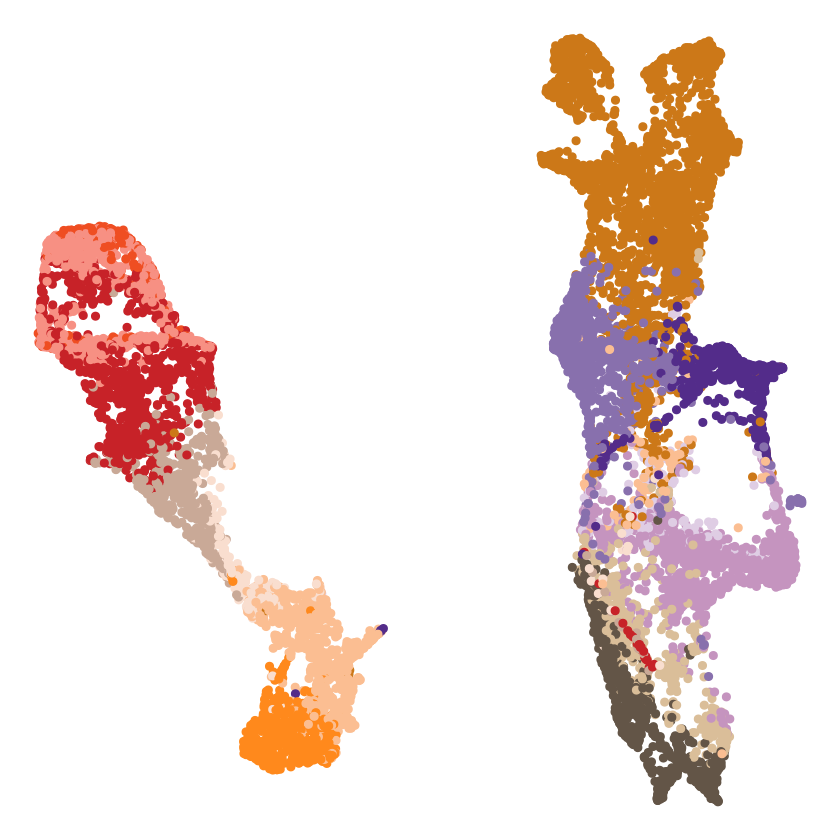

In [141]:
##########
## UMAP ##
##########

# Run
set.seed(args$seed)
args$min_dist = 0.1
args$n_neighbors = 25
reducedDim(sce_filt, "PCA") <- pca.mtx[colnames(sce),]

umap.mtx = umap(pca.corrected[colnames(sce),], 
                n_neighbors = args$n_neighbors,
                min_dist = args$min_dist)

# Fetch UMAP coordinates
umap.dt <- umap.mtx %>% as.data.table %>% 
  .[,cell:=colnames(sce_filt)] %>%
  setnames(c("UMAP1","UMAP2","cell")) %>%
  merge(.,sample_metadata[,c('cell', 'celltype', 'stage')], by='cell')

# Plot umap
ggplot(umap.dt, aes(UMAP1, UMAP2, col=celltype)) + 
    geom_point() + 
    scale_colour_manual(values=opts$celltype.colors) + 
    theme_void() + 
    theme(legend.position="none")

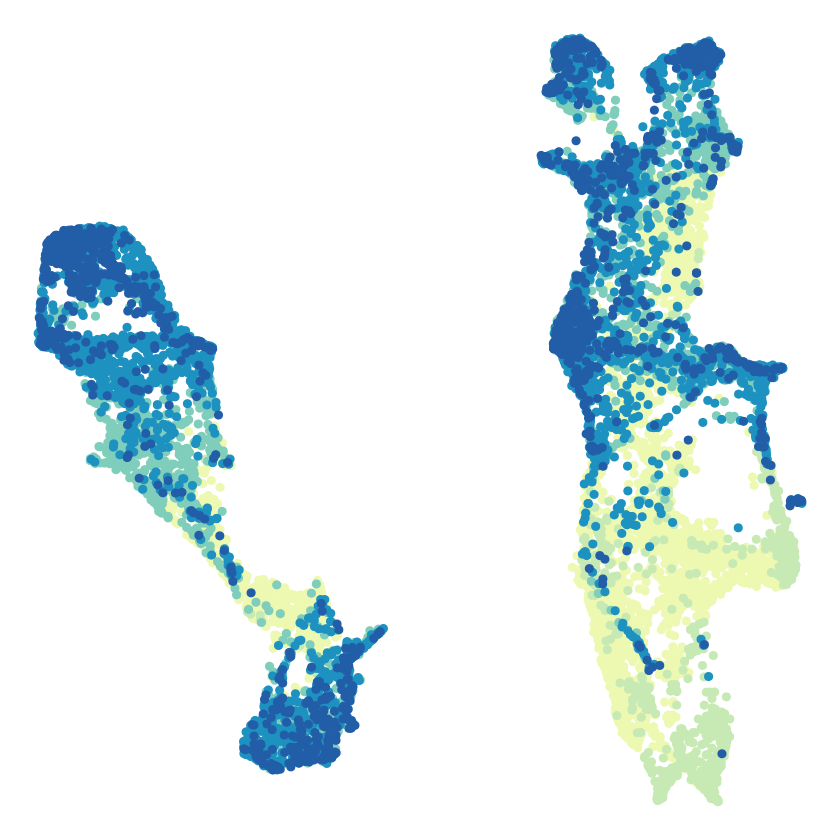

In [143]:
umap.dt <- umap.mtx %>% as.data.table %>% 
  .[,cell:=colnames(sce_filt)] %>%
  setnames(c("UMAP1","UMAP2","cell")) %>%
  merge(.,sample_metadata[,c('cell', 'celltype', 'stage')], by='cell')
ggplot(umap.dt, aes(UMAP1, UMAP2, col=stage)) + 
    geom_point() + 
    scale_colour_manual(values=opts$stage.colors) + 
    theme_void() + 
    theme(legend.position="none")

In [145]:
# Save UMAP coordinates
fwrite(umap.dt, sprintf("%s/umap_features%d_pcs%d_neigh%d_dist%s.txt.gz",args$outdir, args$features, args$npcs, args$n_neighbors, args$min_dist))

In [ ]:
rna_meta = fread(file.path(io$basedir,"results/rna/mapping/sample_metadata_after_mapping.txt.gz"))
atac_meta = fread(file.path(io$basedir, '/results/atac/archR/qc/sample_metadata_after_qc.txt.gz'))

In [ ]:
test = merge(rna_meta, atac_meta, by='cell', keep.all=T)

In [ ]:
atac_meta[cell=='E7.5_rep1#AATCTTGAGCGGGCAA-1']
rna_meta[cell=='E7.5_rep1#AATCTTGAGCGGGCAA-1']

cell,barcode,sample,nFeature_RNA,nCount_RNA,mitochondrial_percent_RNA,ribosomal_percent_RNA,stage,genotype,pass_rnaQC,⋯,celltype,celltype.score,closest.cell,TSSEnrichment_atac,ReadsInTSS_atac,PromoterRatio_atac,NucleosomeRatio_atac,nFrags_atac,BlacklistRatio_atac,pass_atacQC
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<chr>,<chr>,<lgl>,⋯,<chr>,<dbl>,<chr>,<dbl>,<int>,<dbl>,<dbl>,<int>,<dbl>,<lgl>
E7.5_rep1#AATCTTGAGCGGGCAA-1,AATCTTGAGCGGGCAA-1,E7.5_rep1,2859,5485,6.78,8.44,E7.5,WT,TRUE,⋯,Primitive_Streak,0.32,cell_84732,7.41,9538,0.1,1.27,222884,0.02,FALSE


cell,barcode,sample,nFeature_RNA,nCount_RNA,mitochondrial_percent_RNA,ribosomal_percent_RNA,stage,genotype,pass_rnaQC,doublet_score,doublet_call,celltype,celltype.score,closest.cell
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<chr>,<chr>,<lgl>,<dbl>,<lgl>,<chr>,<dbl>,<chr>


In [ ]:
nrow(rna_meta)
nrow(atac_meta)

[1] 86139

[1] 93032

In [37]:
test[cell=='E7.5_rep1#AATCTTGAGCGGGCAA-1']

Warning message in cbind(parts$left, ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”
Warning message in cbind(parts$left, ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”
Warning message in cbind(parts$left, ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”
Warning message in cbind(parts$left, ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”


cell,barcode.x,sample.x,nFeature_RNA.x,nCount_RNA.x,mitochondrial_percent_RNA.x,ribosomal_percent_RNA.x,stage.x,genotype.x,pass_rnaQC.x,⋯,celltype.y,celltype.score.y,closest.cell.y,TSSEnrichment_atac,ReadsInTSS_atac,PromoterRatio_atac,NucleosomeRatio_atac,nFrags_atac,BlacklistRatio_atac,pass_atacQC
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<chr>,<chr>,<lgl>,⋯,<chr>,<dbl>,<chr>,<dbl>,<int>,<dbl>,<dbl>,<int>,<dbl>,<lgl>
